# import libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

In [ ]:
data = pd.read_csv("/content/housing.csv",sep=r"\s+", header = None )
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       506 non-null    float64
 1   1       506 non-null    float64
 2   2       506 non-null    float64
 3   3       506 non-null    int64  
 4   4       506 non-null    float64
 5   5       506 non-null    float64
 6   6       506 non-null    float64
 7   7       506 non-null    float64
 8   8       506 non-null    int64  
 9   9       506 non-null    float64
 10  10      506 non-null    float64
 11  11      506 non-null    float64
 12  12      506 non-null    float64
 13  13      506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [ ]:
y = data.iloc[:,[13]].to_numpy()
x = data.iloc[:,0:13].to_numpy()

scaler = StandardScaler()
x = scaler.fit_transform(x)

x = x.astype(np.float32)
y = y.astype(np.float32)

x = torch.from_numpy(x)
y = torch.from_numpy(y)

In [ ]:
x_train,x_test, y_train, y_test = train_test_split(x,y, train_size = 0.7, random_state = 42)

In [ ]:
train_dataset = TensorDataset(x_train,y_train)
test_dataset = TensorDataset(x_test,y_test)

In [ ]:

train_dataset.tensors


(tensor([[-0.4170, -0.4877, -1.3069,  ...,  0.1130,  0.4106, -1.0433],
         [-0.4052, -0.4877, -0.1644,  ..., -0.3031,  0.4016, -0.0859],
         [-0.4006, -0.4877, -0.6167,  ..., -0.2569,  0.4411, -0.3425],
         ...,
         [-0.4188,  2.9458, -1.3317,  ..., -0.6730,  0.3757, -0.9340],
         [ 0.8783, -0.4877,  1.0160,  ...,  0.8066, -2.7063,  1.4882],
         [-0.3939, -0.4877, -0.3760,  ...,  1.1302, -3.1344, -0.2836]]),
 tensor([[28.7000],
         [21.2000],
         [19.3000],
         [23.1000],
         [19.1000],
         [25.0000],
         [33.4000],
         [ 5.0000],
         [29.6000],
         [18.7000],
         [21.7000],
         [23.1000],
         [22.8000],
         [21.0000],
         [48.8000],
         [14.6000],
         [16.6000],
         [27.1000],
         [20.1000],
         [19.8000],
         [21.0000],
         [41.3000],
         [23.2000],
         [20.4000],
         [18.5000],
         [29.4000],
         [36.4000],
         [24.4000]

In [ ]:
train_loader = DataLoader(train_dataset, batch_size = 50, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 50, shuffle = False)

In [ ]:
model = nn.Sequential(
    nn.Linear(13, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [ ]:
model

Sequential(
  (0): Linear(in_features=13, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=64, bias=True)
  (6): ReLU()
  (7): Linear(in_features=64, out_features=1, bias=True)
)

Epoch 50, Avg Loss: 12.1056
Epoch 100, Avg Loss: 10.7721
Epoch 150, Avg Loss: 7.8166
Epoch 200, Avg Loss: 10.1198
Epoch 250, Avg Loss: 7.3013
Epoch 300, Avg Loss: 8.2917
Epoch 350, Avg Loss: 8.2431
Epoch 400, Avg Loss: 4.7008
Epoch 450, Avg Loss: 3.8633
Epoch 500, Avg Loss: 3.8452
Epoch 550, Avg Loss: 3.5780
Epoch 600, Avg Loss: 3.4328
Epoch 650, Avg Loss: 4.4283
Epoch 700, Avg Loss: 3.0667
Epoch 750, Avg Loss: 2.5880
Epoch 800, Avg Loss: 2.4278
Epoch 850, Avg Loss: 2.2541
Epoch 900, Avg Loss: 2.0481
Epoch 950, Avg Loss: 2.5727
Epoch 1000, Avg Loss: 1.8173


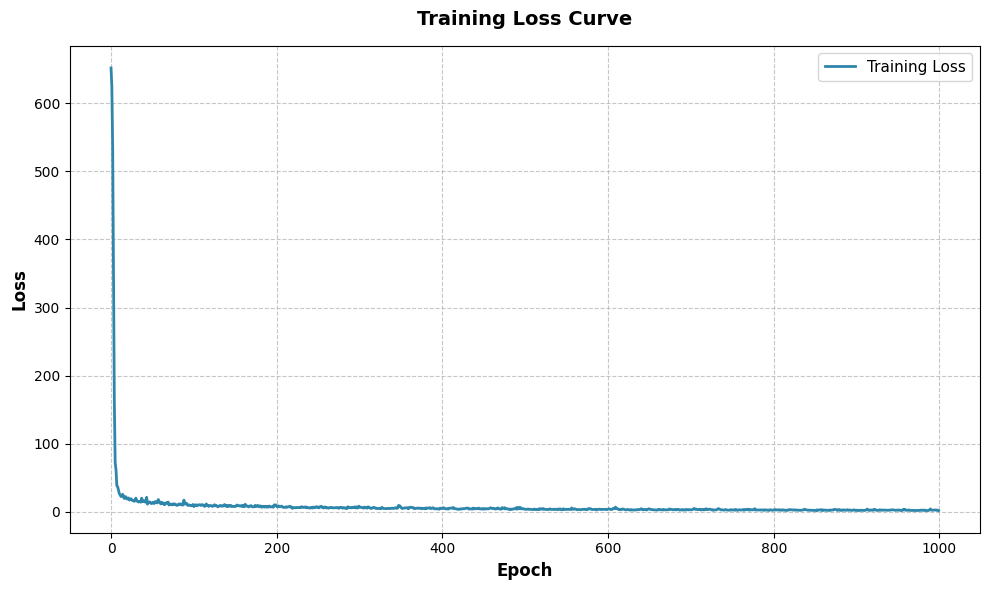


Training completed!
Final loss: 1.817338
Best loss: 1.817338 (Epoch 1000)


In [ ]:
import matplotlib.pyplot as plt

# Track losses for plotting
train_losses = []

for epoch in range(1000):
    running_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)  # Store loss for plotting

    if (epoch + 1) % 50 == 0:  # Print every 50 epochs to reduce clutter
        print(f"Epoch {epoch+1}, Avg Loss: {epoch_loss:.4f}")

# Plot training loss curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='#2E86AB', linewidth=2)
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss Curve', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=300, bbox_inches='tight')  # Save high-res version
plt.show()

# Optional: Print final statistics
print(f"\nTraining completed!")
print(f"Final loss: {train_losses[-1]:.6f}")
print(f"Best loss: {min(train_losses):.6f} (Epoch {train_losses.index(min(train_losses)) + 1})")

In [ ]:
model.eval()
test_loss = 0.0
y_true = []
y_pred = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        output = model(x_batch)
        loss = criterion(output, y_batch)
        test_loss += loss.item()

        y_true.append(y_batch)
        y_pred.append(output)

y_true = torch.cat(y_true, dim=0)
y_pred = torch.cat(y_pred, dim=0)

avg_test_loss = test_loss / len(test_loader)
print(f"Test Loss (MSE): {avg_test_loss:.4f}")

Test Loss (MSE): 7.6784


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true.numpy(), y_pred.numpy())
print(f"R² Score: {r2:.4f}")

R² Score: 0.8708
